# FYP Notebook 2 — Transformer Fine-Tuning (Jigsaw Toxic Comments)
**Student:** Angal Hemanth Reddy | A00088732 · **Supervisor:** Dr. Sayed Pouria Talebi

Fine-tunes **BERT** and **XLM-RoBERTa** for **multi-label** toxicity classification and compares
them against the TF-IDF baseline from Notebook 1.

### Key difference from single-label work
Multi-label ⇒ `BCEWithLogitsLoss`, sigmoid + threshold (not softmax/argmax),
`problem_type="multi_label_classification"`, and float labels.

### ▶ Setup — do these BEFORE running
1. `+ Add Input` → **`jigsaw-toxic-comment-classification-challenge`**
2. **Settings → Accelerator → GPU T4 x2**
3. **Settings → Internet → On**
4. Run All (~2–4 h for both models), then **Save Version**

> **Time saver:** `SAMPLE_SIZE` below caps training data. Start at 60000 to finish in ~1–1.5 h.
> Set to `None` for the full 159k once you know it runs.


## 1 · Setup

In [1]:
import os, re, glob, gc, json, inspect, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")
import torch, torch.nn as nn
from torch.utils.data import Dataset

print("PyTorch", torch.__version__, "| CUDA", torch.cuda.is_available())
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))
else: print("⚠ NO GPU — enable Settings → Accelerator → GPU.")
import transformers; print("transformers", transformers.__version__)

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
TEXT = "comment_text"
NUM_LABELS = len(LABELS)

SAMPLE_SIZE = None     # None = use all ~159k rows
MAX_LEN     = 192      # ~p95 of comment length
EPOCHS      = 2
BATCH       = 16
THRESHOLD   = 0.5      # sigmoid cut-off for turning probabilities into labels


PyTorch 2.10.0+cu128 | CUDA True
GPU: Tesla T4
transformers 5.0.0


## 2 · Load & split

In [2]:
cands = glob.glob("/kaggle/input/**/train.csv", recursive=True)
if not cands:
    raise FileNotFoundError("Add the jigsaw-toxic-comment-classification-challenge dataset.")
df = pd.read_csv(cands[0])
df = df[df[TEXT].notna() & (df[TEXT].astype(str).str.strip().str.len() > 1)]
df = df.drop_duplicates(subset=[TEXT]).reset_index(drop=True)
print(f"Clean rows: {len(df):,}")

from sklearn.model_selection import train_test_split
strat = (df[LABELS].values.sum(axis=1) > 0).astype(int)

if SAMPLE_SIZE and SAMPLE_SIZE < len(df):
    df, _ = train_test_split(df, train_size=SAMPLE_SIZE, random_state=42, stratify=strat)
    df = df.reset_index(drop=True)
    strat = (df[LABELS].values.sum(axis=1) > 0).astype(int)
    print(f"Sampled to {len(df):,} rows (set SAMPLE_SIZE=None for full data)")

tr_df, tmp = train_test_split(df, test_size=0.30, random_state=42, stratify=strat)
s2 = (tmp[LABELS].values.sum(axis=1) > 0).astype(int)
va_df, te_df = train_test_split(tmp, test_size=0.50, random_state=42, stratify=s2)
tr_df, va_df, te_df = [d.reset_index(drop=True) for d in (tr_df, va_df, te_df)]

Y_test = te_df[LABELS].values.astype(int)
print(f"Train {len(tr_df):,} | Val {len(va_df):,} | Test {len(te_df):,}")
print("\nPositive counts in train:"); print(tr_df[LABELS].sum().to_string())


Clean rows: 159,571
Train 111,699 | Val 23,936 | Test 23,936

Positive counts in train:
toxic            10703
severe_toxic      1131
obscene           5933
threat             327
insult            5498
identity_hate      993


## 3 · Multi-label components

In [3]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)
from sklearn.metrics import f1_score, roc_auc_score, classification_report

class MLDataset(Dataset):
    """Multi-label dataset — labels are FLOAT vectors, not integer class ids."""
    def __init__(self, texts, labels, tok, max_len):
        self.t = list(texts); self.y = np.asarray(labels, dtype=np.float32)
        self.tok = tok; self.ml = max_len
    def __len__(self): return len(self.t)
    def __getitem__(self, i):
        e = self.tok(str(self.t[i]), truncation=True, padding="max_length",
                     max_length=self.ml, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in e.items()}
        item["labels"] = torch.tensor(self.y[i], dtype=torch.float)
        return item

def sigmoid(x): return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid(logits)
    preds = (probs >= THRESHOLD).astype(int)
    labels = labels.astype(int)
    aucs = []
    for i in range(labels.shape[1]):
        if len(np.unique(labels[:, i])) > 1:
            aucs.append(roc_auc_score(labels[:, i], probs[:, i]))
    return {
        "micro_f1": f1_score(labels, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "mean_auc": float(np.mean(aucs)) if aucs else 0.0,
    }

# pos_weight counteracts the heavy negative skew of the rare labels
pos = tr_df[LABELS].values.sum(axis=0)
neg = len(tr_df) - pos
pos_weight_t = torch.tensor(np.clip(neg / np.maximum(pos, 1), 1, 50), dtype=torch.float)
print("pos_weight:", {L: round(float(w),1) for L, w in zip(LABELS, pos_weight_t)})

class MultiLabelTrainer(Trainer):
    def __init__(self, pos_weight=None, **kw):
        super().__init__(**kw); self.pos_weight = pos_weight
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        w = self.pos_weight.to(logits.device) if self.pos_weight is not None else None
        loss = nn.BCEWithLogitsLoss(pos_weight=w)(logits, labels.float())
        return (loss, outputs) if return_outputs else loss


pos_weight: {'toxic': 9.4, 'severe_toxic': 50.0, 'obscene': 17.8, 'threat': 50.0, 'insult': 19.3, 'identity_hate': 50.0}


In [4]:
_TA = set(inspect.signature(TrainingArguments.__init__).parameters)
_EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA else "evaluation_strategy"
_HAS_WS = "warmup_steps" in _TA

def make_args(out_dir, lr):
    kw = dict(output_dir=out_dir, num_train_epochs=EPOCHS, learning_rate=lr,
              per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH*2,
              weight_decay=0.01, save_strategy="epoch", load_best_model_at_end=True,
              metric_for_best_model="mean_auc", greater_is_better=True,
              logging_steps=100, save_total_limit=1,
              fp16=torch.cuda.is_available(), report_to="none", seed=42)
    kw[_EVAL_KEY] = "epoch"
    if _HAS_WS:
        kw["warmup_steps"] = max(50, int(0.06 * (len(tr_df)//BATCH + 1) * EPOCHS))
    return TrainingArguments(**kw)

scores = {}
def run(model_name, lr, tag):
    print(f"\n{'='*58}\n{tag}  ({model_name})  lr={lr}\n{'='*58}")
    tok = AutoTokenizer.from_pretrained(model_name)
    tr = MLDataset(tr_df[TEXT], tr_df[LABELS].values, tok, MAX_LEN)
    va = MLDataset(va_df[TEXT], va_df[LABELS].values, tok, MAX_LEN)
    te = MLDataset(te_df[TEXT], te_df[LABELS].values, tok, MAX_LEN)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS,
        problem_type="multi_label_classification")   # <- critical for multi-label

    trainer = MultiLabelTrainer(
        pos_weight=pos_weight_t, model=model, args=make_args(f"./{tag}", lr),
        train_dataset=tr, eval_dataset=va, compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)])
    trainer.train()

    logits = trainer.predict(te).predictions
    probs = sigmoid(logits); preds = (probs >= THRESHOLD).astype(int)
    aucs = [roc_auc_score(Y_test[:, i], probs[:, i])
            for i in range(NUM_LABELS) if len(np.unique(Y_test[:, i])) > 1]
    scores[tag] = {"mean_auc": float(np.mean(aucs)),
                   "micro_f1": f1_score(Y_test, preds, average="micro", zero_division=0),
                   "macro_f1": f1_score(Y_test, preds, average="macro", zero_division=0)}
    print(f"\n{tag} — TEST")
    print(classification_report(Y_test, preds, target_names=LABELS, digits=4, zero_division=0))
    print({k: round(v, 4) for k, v in scores[tag].items()})

    del model, trainer; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return probs, preds

print("Ready | eval key:", _EVAL_KEY)


Ready | eval key: eval_strategy


## 4 · Fine-tune BERT

In [5]:
bert_prob, bert_pred = run("bert-base-uncased", 2e-5, "BERT")


BERT  (bert-base-uncased)  lr=2e-05


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Mean Auc
1,0.237325,0.232367,0.697364,0.588984,0.985050
2,0.162243,0.222320,0.717059,0.620836,0.989472


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


BERT — TEST
               precision    recall  f1-score   support

        toxic     0.6930    0.9251    0.7924      2296
 severe_toxic     0.2663    0.9485    0.4158       233
      obscene     0.6436    0.9662    0.7726      1271
       threat     0.4231    0.7857    0.5500        84
       insult     0.5755    0.9493    0.7166      1204
identity_hate     0.3717    0.8221    0.5120       208

    micro avg     0.5893    0.9352    0.7230      5296
    macro avg     0.4955    0.8995    0.6266      5296
 weighted avg     0.6188    0.9352    0.7390      5296
  samples avg     0.0661    0.0911    0.0738      5296

{'mean_auc': 0.9895, 'micro_f1': 0.723, 'macro_f1': 0.6266}


## 5 · Fine-tune XLM-RoBERTa

In [6]:
xlmr_prob, xlmr_pred = run("xlm-roberta-base", 1e-5, "XLM-R")


XLM-R  (xlm-roberta-base)  lr=1e-05


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Mean Auc
1,0.303882,0.260289,0.575410,0.437289,0.979215
2,0.229382,0.239234,0.640451,0.493197,0.983018


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


XLM-R — TEST
               precision    recall  f1-score   support

        toxic     0.6675    0.9329    0.7782      2296
 severe_toxic     0.2349    0.9700    0.3782       233
      obscene     0.5732    0.9638    0.7189      1271
       threat     0.1353    0.6667    0.2249        84
       insult     0.5035    0.9510    0.6584      1204
identity_hate     0.1665    0.8077    0.2761       208

    micro avg     0.4960    0.9369    0.6486      5296
    macro avg     0.3802    0.8820    0.5058      5296
 weighted avg     0.5604    0.9369    0.6906      5296
  samples avg     0.0590    0.0917    0.0686      5296

{'mean_auc': 0.9823, 'micro_f1': 0.6486, 'macro_f1': 0.5058}


## 6 · Comparison with the Notebook 1 baseline

baseline_scores.json not found — run Notebook 1 first, or enter its numbers manually.
Model  Mean ROC AUC  Micro F1  Macro F1
 BERT        0.9895    0.7230    0.6266
XLM-R        0.9823    0.6486    0.5058


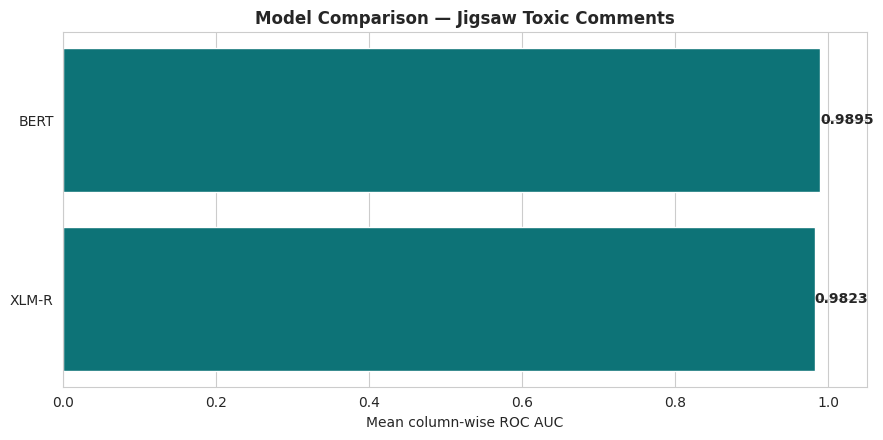


>>> Click 'Save Version' now. <<<


In [7]:
rows = []
bp = "/kaggle/working/baseline_scores.json"
if os.path.exists(bp):
    b = json.load(open(bp))
    rows.append({"Model": "TF-IDF + OvR LogReg", **{k: round(b[k],4) for k in
                 ("mean_auc","micro_f1","macro_f1")}})
else:
    print("baseline_scores.json not found — run Notebook 1 first, or enter its numbers manually.")

for tag in ["BERT", "XLM-R"]:
    if tag in scores:
        rows.append({"Model": tag, **{k: round(v,4) for k, v in scores[tag].items()}})

res = pd.DataFrame(rows).rename(columns={"mean_auc":"Mean ROC AUC",
                                          "micro_f1":"Micro F1","macro_f1":"Macro F1"})
res = res.sort_values("Mean ROC AUC", ascending=False).reset_index(drop=True)
print(res.to_string(index=False))
res.to_csv("/kaggle/working/jigsaw_model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(9,4.5))
r = res.sort_values("Mean ROC AUC")
bars = ax.barh(r["Model"], r["Mean ROC AUC"], color="#0D7377")
for b_, v in zip(bars, r["Mean ROC AUC"]):
    ax.annotate(f"{v:.4f}", (b_.get_width(), b_.get_y()+b_.get_height()/2),
                va="center", ha="left", fontweight="bold")
ax.set_xlim(0, 1.05); ax.set_xlabel("Mean column-wise ROC AUC")
ax.set_title("Model Comparison — Jigsaw Toxic Comments", fontweight="bold")
plt.tight_layout(); plt.show()
print("\n>>> Click 'Save Version' now. <<<")


## 7 · Per-label detail & error analysis

In [8]:
best = "BERT" if scores.get("BERT",{}).get("mean_auc",0) >= scores.get("XLM-R",{}).get("mean_auc",0) else "XLM-R"
bp_ = bert_prob if best == "BERT" else xlmr_prob
bd_ = bert_pred if best == "BERT" else xlmr_pred
print("Best model:", best)

per = pd.DataFrame({
    "label": LABELS,
    "support": Y_test.sum(axis=0),
    "auc": [roc_auc_score(Y_test[:,i], bp_[:,i]) if len(np.unique(Y_test[:,i]))>1 else np.nan
            for i in range(NUM_LABELS)],
    "f1": [f1_score(Y_test[:,i], bd_[:,i], zero_division=0) for i in range(NUM_LABELS)],
}).sort_values("support", ascending=False)
print(per.round(4).to_string(index=False))
print("\nNote how F1 falls on rare labels while AUC stays high — a threshold effect,")
print("not a failure to rank. Tuning THRESHOLD per label would raise F1.")


Best model: BERT
        label  support    auc     f1
        toxic     2296 0.9863 0.7924
      obscene     1271 0.9934 0.7726
       insult     1204 0.9893 0.7166
 severe_toxic      233 0.9924 0.4158
identity_hate      208 0.9873 0.5120
       threat       84 0.9885 0.5500

Note how F1 falls on rare labels while AUC stays high — a threshold effect,
not a failure to rank. Tuning THRESHOLD per label would raise F1.


In [12]:
rows.append({"Model": "TF-IDF + OvR LogReg",
             "mean_auc": 0.9772, "micro_f1": 0.7036, "macro_f1": 0.5860})